nested sampling, bayesian evidence

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import emcee

In [2]:
import corner

In [3]:
import scipy.stats

In [4]:
import dynesty
from dynesty import utils as dyfunc
from dynesty import plotting as dyplot

In [5]:
import warnings

In [6]:
data = np.load("transient.npy")

<ErrorbarContainer object of 3 artists>

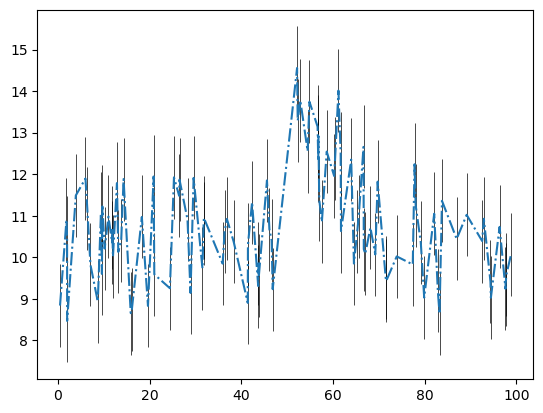

In [7]:
plt.errorbar(data[:,0], data[:,1], data[:,2], fmt="-.", ecolor = "black", elinewidth=0.5)

In [8]:
def model1(params, t):
    A, b, t0, alpha = params
    arr = []
    for i in t:
        if i<t0:    arr.append(b)
        else:       arr.append(b + A*np.exp(-alpha*(i-t0)))
    arr = np.array(arr)

    return arr

def model2(params, t):
    A, b, t0, sigmaw = params
    return b + A*np.exp(-(t-t0)**2 / (2*sigmaw**2))
    

In [9]:
t0min,t0max = 0,100
Amin,Amax=0,50
bmin,bmax=0,50
alphamin,alphamax=np.exp(-5),np.exp(5)
sigmaWmin = 0.5*np.exp(-2.5)
sigmaWmax = 0.5*np.exp(2.5)

In [10]:
a =np.nan
print(a)

nan


In [11]:
ndim = 4

def loglike(theta, data, model):
    x, y, sigma_y = data.T
    if model == 1:
        y_fit = model1(theta, x)
    elif model == 2:
        y_fit = model2(theta, x)

    # Note I'm not tracking the normalization here! 
    # Ok because here I only care about the ratio between two evidences, not the evidence itself
    return -0.5 * np.sum((y-y_fit)**2 / sigma_y**2 ) 



def ptform(u, model):


    #for i in u[0]:              'numpy.float64' object is not iterable so it gives ptform one value at a time, why
    if 0 <= u[0] <= 1:
        A = Amin + (Amax-Amin)*((u[0]-0)/(1-0))
    else: A = np.nan

   
    if 0 <= u[1] <= 1:
        b = bmin + (bmax-bmin)*((u[1]-0)/(1-0))
    else: b = np.nan

    
    if 0 < u[2] < 1:
        t0 = t0min + (t0max-t0min)*((u[2]-0)/(1-0))
    else: t0 = np.nan


    if model == 1:
        model_dependent = scipy.stats.loguniform.ppf(u[3],alphamin,alphamax)
    elif model == 2:
        model_dependent = scipy.stats.loguniform.ppf(u[3],sigmaWmin,sigmaWmax)


    #this was before when I confused the u limits, but now that I know they are 0<u<1 I'm not sure how to a loguniform distribution
    #I could try just switching alphamin and alphamax with 0 and 1
    # if model == 1:
    #     if np.log10(alphamin) < np.log10(u[3]) < np.log10(alphamax):
    #         model_dependent = 0 + (1-0)*((np.log10(u[3])-np.log10(alphamin))/(np.log10(alphamax)-np.log10(alphamin)))
    #     else: model_dependent = np.nan

    # if model == 2:
    #     if np.log10(sigmaWmin) < np.log10(u[3]) < np.log10(sigmaWmax):
    #         model_dependent = 0 + (1-0)*((np.log10(u[3])-np.log10(sigmaWmin))/(np.log10(sigmaWmax)-np.log10(sigmaWmin)))
    #     else: model_dependent = np.nan

    return [A, b, t0, model_dependent]

#my prior transformation is not working

In [12]:
# def ptform(u,model):
#     """Transforms the uniform random variables `u ~ Unif[0., 1.)`
#     to the parameters of interest."""

#     x = np.array(u)  # copy u

#     x[0] = scipy.stats.uniform(loc=Amin,scale=Amax-Amin).ppf(u[0])
#     x[1] = scipy.stats.uniform(loc=bmin,scale=bmax-bmin).ppf(u[1])
#     x[2] = scipy.stats.uniform(loc=t0min,scale=t0max-t0min).ppf(u[2])
   
#     if model == 1:
#         x[3] = scipy.stats.loguniform.ppf(u[3],alphamin,alphamax)
#     elif model == 2:
#         x[3] = scipy.stats.loguniform.ppf(u[3],sigmaWmin,sigmaWmax)
#         #x[3] = scipy.stats.uniform(loc=sigmaWmin,scale=sigmaWmax-sigmaWmin).ppf(u[3])

#     return x

In [13]:
with warnings.catch_warnings():
    # Potentially dangerous, but hey I know what I'm doing. 
    # Those warnings come from regions where the likelihood is ~zero
    warnings.simplefilter("ignore", category=RuntimeWarning)

    # Define and run sampler
    sampler = dynesty.NestedSampler(loglike, ptform, ndim, logl_args=[data,1], ptform_args=[1], nlive=300)
    sampler.run_nested()
    sresults = sampler.results

#2 minuti e 27 secondi
#35 seconds with my prior transform

2395it [00:20, 31.66it/s, bound: 88 | nc: 70 | ncall: 50434 | eff(%):  4.749 | loglstar:   -inf < -86.522 <    inf | logz: -93.393 +/-  0.139 | dlogz: 35.749 >  0.309]    c:\Users\albad\.conda\envs\astr\lib\site-packages\dynesty\bounding.py:618: UserWarning: The enlargement factor for the ellipsoidal bounds determined from bootstrapping is very large. If you are using uniform sampling that may mean that the sampling will be inefficient. This may be caused by a very complex posterior shape. You may consider using more livepoints or different sampler (i.e. rslice or rwalk) or alternatively disable bootstrap (bootstrap=0)
  warnings.warn(
2407it [00:21, 15.06it/s, bound: 94 | nc: 210 | ncall: 52937 | eff(%):  4.547 | loglstar:   -inf < -86.380 <    inf | logz: -93.379 +/-  0.139 | dlogz: 35.695 >  0.309]c:\Users\albad\.conda\envs\astr\lib\site-packages\dynesty\bounding.py:618: UserWarning: The enlargement factor for the ellipsoidal bounds determined from bootstrapping is very large. If yo

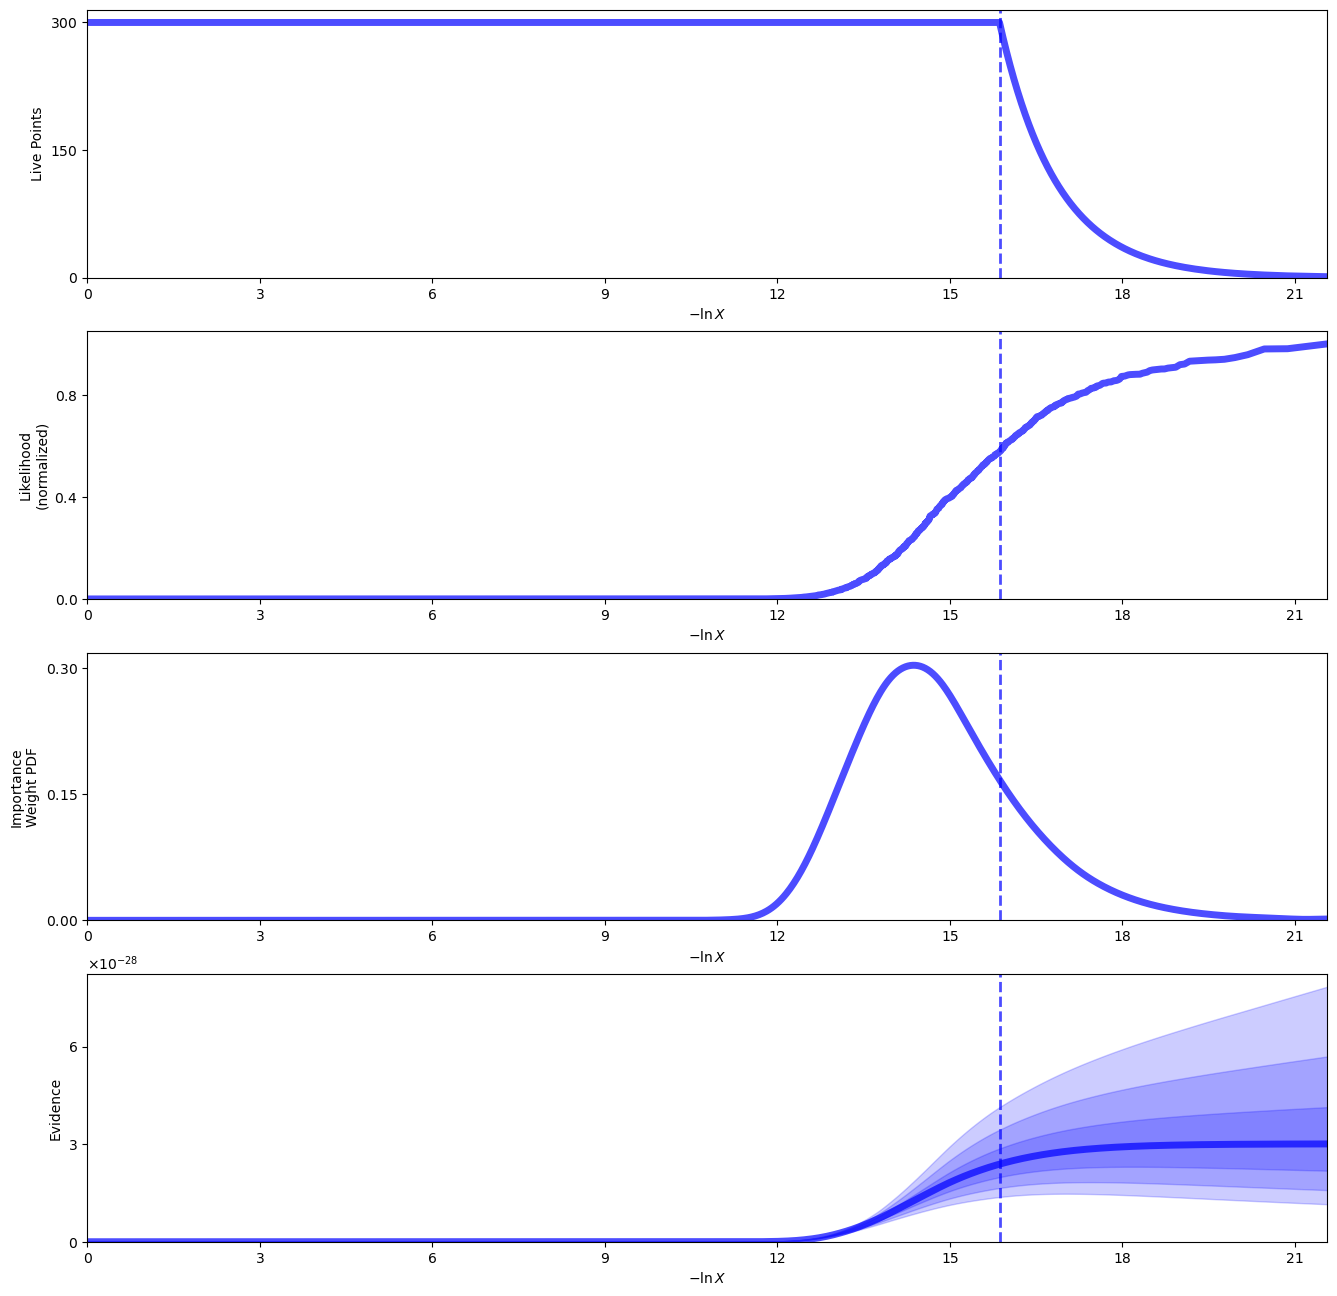

In [14]:
rfig, raxes = dyplot.runplot(sresults)

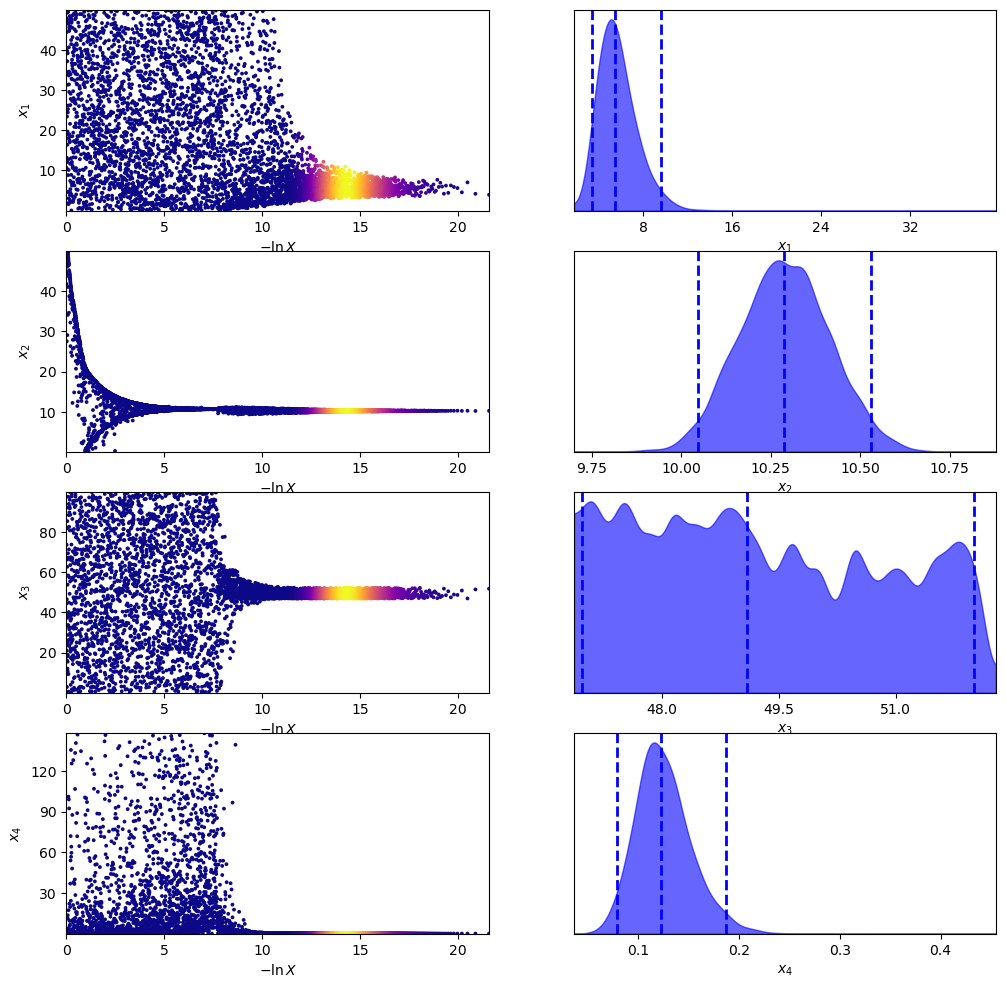

In [15]:
tfig, taxes = dyplot.traceplot(sresults)

In [16]:
samples = sresults.samples
#wanted to see what the weights looked like

In [17]:
print(samples)

[[4.98375870e+01 4.62121111e+01 4.43281101e+01 1.04308638e-02]
 [3.95175408e+01 4.91437310e+01 1.90140048e+01 1.92658177e-02]
 [3.99997474e+01 4.16905227e+01 2.24061732e-02 1.38717742e-02]
 ...
 [7.02521330e+00 1.03115175e+01 4.69275314e+01 1.20751839e-01]
 [4.17629434e+00 1.02592901e+01 5.14209589e+01 1.15530754e-01]
 [3.93807329e+00 1.02909082e+01 5.17430509e+01 1.15947617e-01]]


(array([ 230.,  206.,  267.,  250., 1859., 1255.,  259.,  230.,  265.,
         245.]),
 array([2.24061732e-02, 1.00200279e+01, 2.00176497e+01, 3.00152715e+01,
        4.00128932e+01, 5.00105150e+01, 6.00081368e+01, 7.00057586e+01,
        8.00033803e+01, 9.00010021e+01, 9.99986239e+01]),
 <BarContainer object of 10 artists>)

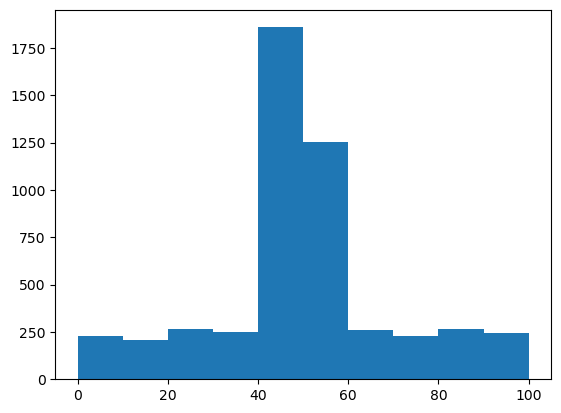

In [18]:
plt.hist(samples[:,2])

In [19]:
weights = np.exp(sresults.logwt - sresults.logz[-1])  # normalized weights

In [20]:
print(weights)

[0.         0.         0.         ... 0.00092069 0.00093178 0.00094127]


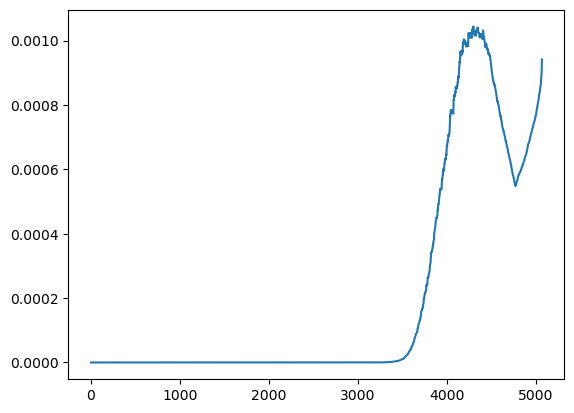

In [21]:
plt.plot(weights)

(array([3669.,   78.,   68.,   51.,   51.,  214.,  240.,  200.,  149.,
         346.]),
 array([0.        , 0.00010436, 0.00020872, 0.00031308, 0.00041743,
        0.00052179, 0.00062615, 0.00073051, 0.00083487, 0.00093923,
        0.00104359]),
 <BarContainer object of 10 artists>)

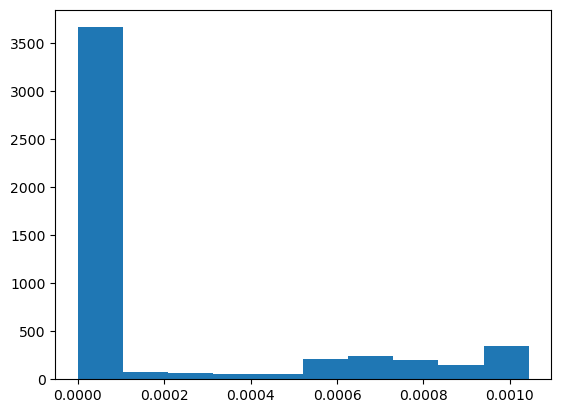

In [22]:
plt.hist(weights)

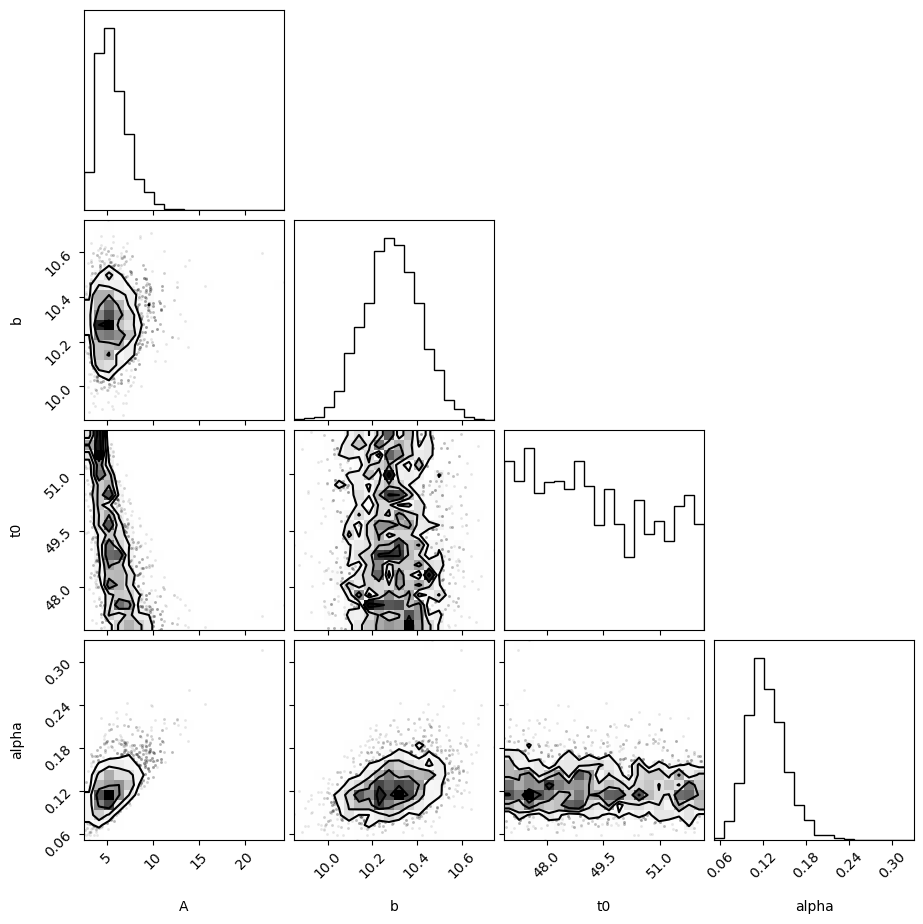

In [23]:
labels = ["A","b","t0","alpha"]

samples_equal = dyfunc.resample_equal(samples, weights)
corner.corner(samples_equal,labels=labels);

In [24]:
quantiles = [dyfunc.quantile(samps, [0.05, 0.5, 0.95], weights=weights) for samps in samples.T]
for q,l in zip(quantiles,labels):
    low,med,up=q
    print(l+"   "+str(med)+" +"+str(up-med)+" -"+str(med-low))

A   5.427074485192044 +3.3515444185581895 -1.8753351132693625
b   10.285944660712147 +0.21130123386529398 -0.19743890604538272
t0   49.09284883450064 +2.782062201660885 -2.011676897346838
alpha   0.12232646501701673 +0.05245584404600957 -0.0359157036204953


In [25]:
sresults.summary()

Summary
nlive: 300
niter: 4766
ncall: 94183
eff(%):  5.379
logz: -63.372 +/-  0.320


In [26]:
sampler = dynesty.NestedSampler(loglike, ptform, ndim, logl_args=[data,2], ptform_args=[2], nlive=300)      #, bootstrap=0
sampler.run_nested()
sresults2 = sampler.results

#3 minuti e 7 secondi
#mi dava un warning
#c:\Users\albad\.conda\envs\astr\lib\site-packages\dynesty\bounding.py:618: UserWarning: The enlargement factor for the ellipsoidal bounds determined from bootstrapping is very large. If you are using uniform sampling that may mean that the sampling will be inefficient. This may be caused by a very complex posterior shape. You may consider using more livepoints or different sampler (i.e. rslice or rwalk) or alternatively disable bootstrap (bootstrap=0)
#quindi bootstrap = 0
#1 minuto e 5 secondi ma forse è per della cache

#I removed bootstrap=0, it takes 30 seconds and it works

2478it [00:19, 11.22it/s, bound: 106 | nc: 801 | ncall: 57614 | eff(%):  4.301 | loglstar:   -inf < -86.493 <    inf | logz: -93.581 +/-  0.141 | dlogz: 31.842 >  0.309]  c:\Users\albad\.conda\envs\astr\lib\site-packages\dynesty\bounding.py:618: UserWarning: The enlargement factor for the ellipsoidal bounds determined from bootstrapping is very large. If you are using uniform sampling that may mean that the sampling will be inefficient. This may be caused by a very complex posterior shape. You may consider using more livepoints or different sampler (i.e. rslice or rwalk) or alternatively disable bootstrap (bootstrap=0)
  warnings.warn(
c:\Users\albad\.conda\envs\astr\lib\site-packages\dynesty\bounding.py:618: UserWarning: The enlargement factor for the ellipsoidal bounds determined from bootstrapping is very large. If you are using uniform sampling that may mean that the sampling will be inefficient. This may be caused by a very complex posterior shape. You may consider using more live

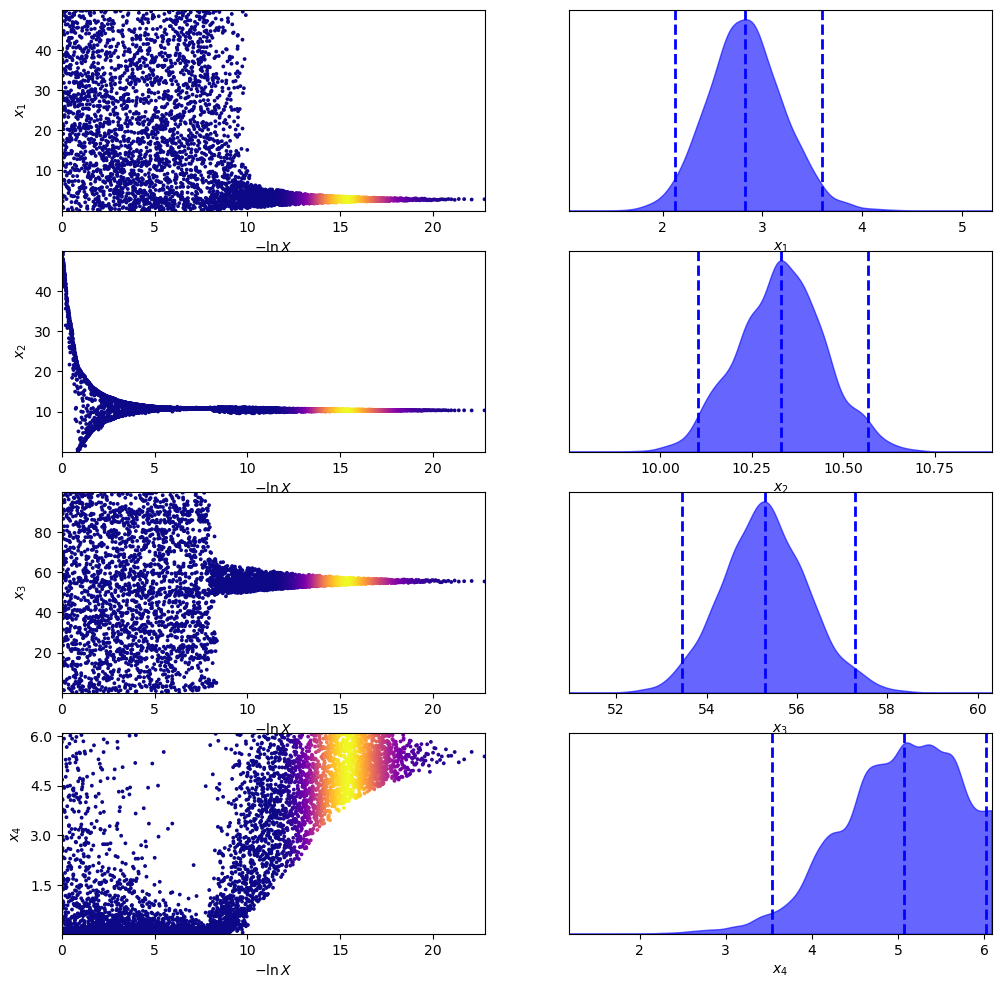

In [27]:
tfig, taxes = dyplot.traceplot(sresults2)

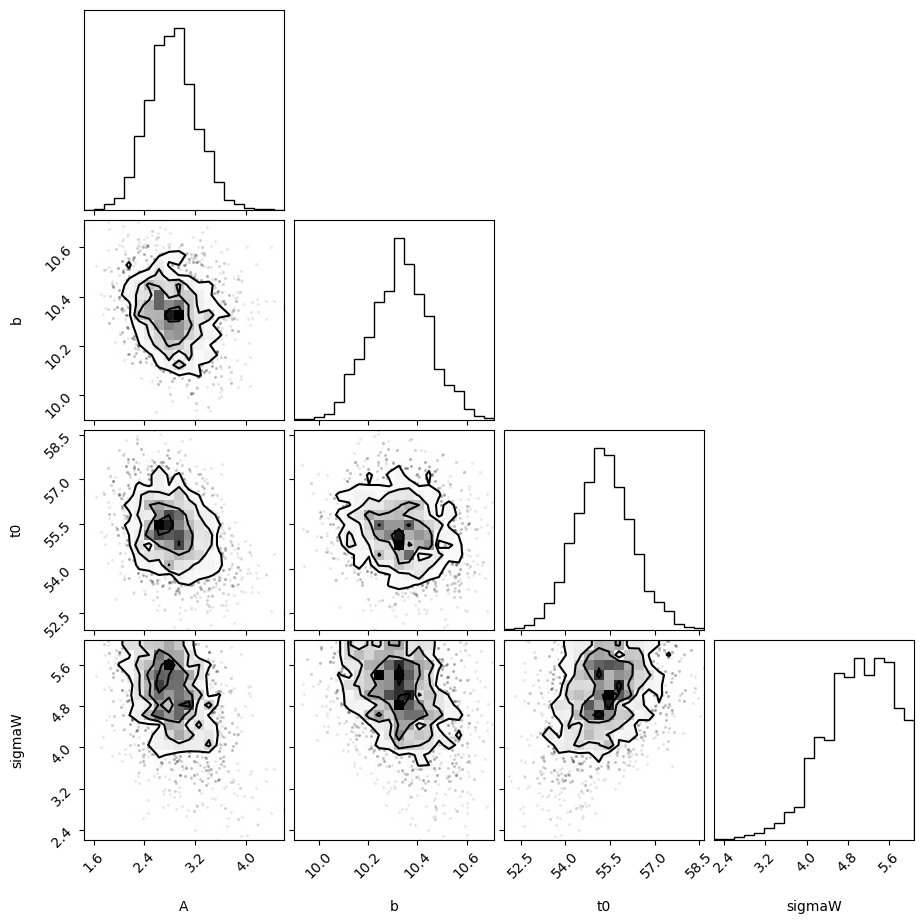

In [28]:
samples = sresults2.samples  # samples
weights = np.exp(sresults2.logwt - sresults2.logz[-1])  # normalized weights

labels = ["A","b","t0","sigmaW"]

samples_equal = dyfunc.resample_equal(samples, weights)
corner.corner(samples_equal,labels=labels);

In [29]:
sresults2.summary()

Summary
nlive: 300
niter: 5129
ncall: 122577
eff(%):  4.429
logz: -68.273 +/-  0.329


In [30]:
print(sresults.logz)

[-1.74087413e+05 -1.49537749e+05 -1.46601907e+05 ... -6.33734977e+01
 -6.33725646e+01 -6.33716229e+01]


In [31]:
np.exp(sresults.logz[-1])/np.exp(sresults2.logz[-1])

134.41187423393754